In [ ]:
##1 Business Problem

SuperMart wants to understand its sales and profitability performance and identify the key factors driving business results.
The analysis will investigate revenue, profit, customers, products, regions and operational performance 
to identify important trends and opportunities.The goal is to provide data-driven insights 
that can support better business decisions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Matplotlib is building the font cache; this may take a moment.


In [ ]:
##2 Data Loading & Understanding

The dataset is loaded into Python using Pandas.

The initial review focuses on understanding the dataset structure, including the number of records, columns, data types and key business variables.

This step establishes what data is available before cleaning and analysis begin.

In [3]:
customers = pd.read_excel(
    "SuperMart_Python_Analytics_Dataset.xlsx",
    sheet_name="Customers"
)

In [4]:
products = pd.read_excel(
    "SuperMart_Python_Analytics_Dataset.xlsx",
    sheet_name="Products"
)

In [5]:
sales = pd.read_excel(
    "SuperMart_Python_Analytics_Dataset.xlsx",
    sheet_name="Sales"
)

In [6]:
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Sales:", sales.shape)

Customers: (50, 8)
Products: (20, 5)
Sales: (800, 21)


In [7]:
sales.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,ProductName,Category,UnitCost,UnitPrice,Region,...,Revenue,DiscountAmount,NetRevenue,Cost,Profit,ProfitMarginPct,OrderStatus,DeliveryDays,OnTime,Returned
0,50001,2025-06-20,1007,2015,9,Cheese 500g,Dairy,55,84.99,KwaZulu-Natal,...,764.91,114.7365,650.1735,495,155.1735,23.866476,Completed,4.0,No,No
1,50002,2026-06-25,1029,2011,5,Potato Chips,Snacks,12,24.99,Eastern Cape,...,124.95,0.0000,124.9500,60,64.9500,51.980792,Completed,6.0,No,Yes
2,50003,2025-02-05,1008,2010,10,Orange Juice,Beverages,25,44.99,KwaZulu-Natal,...,449.90,67.4850,382.4150,250,132.4150,34.625995,Completed,4.0,No,No
3,50004,2026-06-09,1001,2003,5,Rice 10kg,Groceries,120,179.99,Eastern Cape,...,899.95,44.9975,854.9525,600,254.9525,29.820663,Cancelled,1.0,Yes,Yes
4,50005,2025-06-09,1003,2014,2,Toilet Paper,Household,70,109.99,KwaZulu-Natal,...,219.98,10.9990,208.9810,140,68.9810,33.008264,Completed,3.0,Yes,No


In [8]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          800 non-null    int64         
 1   OrderDate        800 non-null    datetime64[us]
 2   CustomerID       800 non-null    int64         
 3   ProductID        800 non-null    int64         
 4   Quantity         800 non-null    int64         
 5   ProductName      800 non-null    str           
 6   Category         800 non-null    str           
 7   UnitCost         800 non-null    int64         
 8   UnitPrice        800 non-null    float64       
 9   Region           800 non-null    str           
 10  DiscountPct      797 non-null    float64       
 11  Revenue          800 non-null    float64       
 12  DiscountAmount   800 non-null    float64       
 13  NetRevenue       800 non-null    float64       
 14  Cost             800 non-null    int64         
 15  

In [9]:
sales.describe()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,UnitCost,UnitPrice,DiscountPct,Revenue,DiscountAmount,NetRevenue,Cost,Profit,ProfitMarginPct,DeliveryDays
count,800.0000,800,800.000000,800.000000,800.000000,800.000000,800.000000,797.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,798.000000
mean,50400.5000,2025-09-19 00:36:00,1025.846250,2010.508750,6.402500,341.367500,506.023512,0.067227,3371.625800,228.304693,3143.321107,2274.948750,868.372357,33.095975,3.295739
min,50001.0000,2025-01-01 00:00:00,1001.000000,2001.000000,1.000000,9.000000,17.990000,0.000000,17.990000,0.000000,16.550800,9.000000,7.540000,18.716430,1.000000
25%,50200.7500,2025-05-06 00:00:00,1014.000000,2005.000000,3.000000,23.000000,40.490000,0.030000,179.900000,5.689725,169.099000,100.000000,62.926250,28.561223,2.000000
50%,50400.5000,2025-09-10 00:00:00,1026.000000,2010.500000,6.000000,65.000000,99.990000,0.050000,509.940000,24.142500,482.206500,325.000000,152.971500,32.060971,3.000000
75%,50600.2500,2026-02-02 12:00:00,1038.000000,2015.000000,9.000000,100.000000,145.000000,0.100000,1259.930000,83.994000,1139.890750,817.500000,318.901000,35.705101,5.000000
max,50800.0000,2026-06-30 00:00:00,1050.000000,2020.000000,12.000000,3800.000000,5499.990000,0.150000,65999.880000,9899.982000,65999.880000,45600.000000,20399.880000,51.980792,6.000000
std,231.0844,NaN,14.118845,5.752503,3.498327,877.510863,1272.385056,0.046597,10071.903759,828.234114,9479.534802,6943.934807,2580.443076,7.051945,1.588148


In [10]:
sales.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'ProductID', 'Quantity',
       'ProductName', 'Category', 'UnitCost', 'UnitPrice', 'Region',
       'DiscountPct', 'Revenue', 'DiscountAmount', 'NetRevenue', 'Cost',
       'Profit', 'ProfitMarginPct', 'OrderStatus', 'DeliveryDays', 'OnTime',
       'Returned'],
      dtype='str')

In [ ]:
##3.Data Cleaning & Quality

Before analysing the data, its quality is assessed to identify issues that could affect the reliability of the results.
The review focuses on missing values, duplicate records, incorrect data types, inconsistent values and potential outliers.
Any relevant issues are addressed before continuing with the analysis.

In [11]:
sales.isnull().sum()


OrderID            0
OrderDate          0
CustomerID         0
ProductID          0
Quantity           0
ProductName        0
Category           0
UnitCost           0
UnitPrice          0
Region             0
DiscountPct        3
Revenue            0
DiscountAmount     0
NetRevenue         0
Cost               0
Profit             0
ProfitMarginPct    0
OrderStatus        0
DeliveryDays       2
OnTime             0
Returned           0
dtype: int64

In [12]:
missing_values = sales.isnull().sum()
missing_values[missing_values > 0]

DiscountPct     3
DeliveryDays    2
dtype: int64

In [13]:
missing_percentage = (sales.isnull().sum() / len(sales)) * 100

missing_percentage[missing_percentage > 0]

DiscountPct     0.375
DeliveryDays    0.250
dtype: float64

In [14]:
sales.duplicated().sum()

np.int64(0)

In [15]:
sales["OrderID"].duplicated().sum()


np.int64(0)

In [16]:
sales.dtypes

OrderID                     int64
OrderDate          datetime64[us]
CustomerID                  int64
ProductID                   int64
Quantity                    int64
ProductName                   str
Category                      str
UnitCost                    int64
UnitPrice                 float64
Region                        str
DiscountPct               float64
Revenue                   float64
DiscountAmount            float64
NetRevenue                float64
Cost                        int64
Profit                    float64
ProfitMarginPct           float64
OrderStatus                   str
DeliveryDays              float64
OnTime                        str
Returned                      str
dtype: object

In [17]:
print("Categories:")
print(sales["Category"].unique())

print("\nRegions:")
print(sales["Region"].unique())

print("\nOrder Status:")
print(sales["OrderStatus"].unique())

Categories:
<StringArray>
[        'Dairy',        'Snacks',     'Beverages',     'Groceries',
     'Household', 'Fresh Produce',      'Cleaning',        'Bakery',
   'Electronics', 'Personal Care']
Length: 10, dtype: str

Regions:
<StringArray>
['KwaZulu-Natal', 'Eastern Cape', 'Gauteng', 'Western Cape', 'Free State']
Length: 5, dtype: str

Order Status:
<StringArray>
['Completed', 'Cancelled', 'Pending']
Length: 3, dtype: str


In [18]:
print("Quantity:")
print(sales["Quantity"].min(), sales["Quantity"].max())

print("\nDiscount:")
print(sales["DiscountPct"].min(), sales["DiscountPct"].max())

print("\nDelivery Days:")
print(sales["DeliveryDays"].min(), sales["DeliveryDays"].max())

Quantity:
1 12

Discount:
0.0 0.15

Delivery Days:
1.0 6.0


In [19]:
sales.nlargest(10, "NetRevenue")[
    ["OrderID", "ProductName", "Quantity", "DiscountPct", "NetRevenue", "Profit"]
]

,OrderID,ProductName,Quantity,DiscountPct,NetRevenue,Profit
57,50058,LED Television,12,0.00,65999.8800,20399.8800
232,50233,LED Television,12,0.00,65999.8800,20399.8800
706,50707,LED Television,12,0.00,65999.8800,20399.8800
192,50193,LED Television,12,0.05,62699.8860,17099.8860
237,50238,LED Television,12,0.05,62699.8860,17099.8860
259,50260,LED Television,12,0.05,62699.8860,17099.8860
565,50566,LED Television,12,0.05,62699.8860,17099.8860
607,50608,LED Television,11,0.00,60499.8900,18699.8900
32,50033,LED Television,12,0.10,59399.8920,13799.8920
165,50166,LED Television,11,0.05,57474.8955,15674.8955


In [20]:
sales[sales["DiscountPct"].isnull()]


,OrderID,OrderDate,CustomerID,ProductID,Quantity,ProductName,Category,UnitCost,UnitPrice,Region,...,Revenue,DiscountAmount,NetRevenue,Cost,Profit,ProfitMarginPct,OrderStatus,DeliveryDays,OnTime,Returned
17,50018,2026-01-12,1032,2020,9,Microwave Oven,Electronics,1200,1799.99,Eastern Cape,...,16199.91,2429.9865,13769.9235,10800,2969.9235,21.568192,Completed,4.0,No,No
88,50089,2025-05-11,1029,2004,9,Coca-Cola 2L,Beverages,17,26.99,Eastern Cape,...,242.91,12.1455,230.7645,153,77.7645,33.698641,Completed,2.0,Yes,No
245,50246,2025-09-15,1044,2017,9,Beef Mince 1kg,Fresh Produce,100,159.99,Western Cape,...,1439.91,71.9955,1367.9145,900,467.9145,34.206414,Cancelled,2.0,Yes,No


In [21]:
sales[sales["DeliveryDays"].isnull()]

,OrderID,OrderDate,CustomerID,ProductID,Quantity,ProductName,Category,UnitCost,UnitPrice,Region,...,Revenue,DiscountAmount,NetRevenue,Cost,Profit,ProfitMarginPct,OrderStatus,DeliveryDays,OnTime,Returned
31,50032,2026-03-18,1007,2020,2,Microwave Oven,Electronics,1200,1799.99,KwaZulu-Natal,...,3599.98,359.9980,3239.9820,2400,839.9820,25.925514,Completed,NaN,No,No
420,50421,2025-03-06,1016,2006,11,Chocolate Bar,Snacks,9,17.99,Western Cape,...,197.89,9.8945,187.9955,99,88.9955,47.339165,Cancelled,NaN,Yes,No


In [22]:
sales_clean = sales.copy()

In [23]:
sales_clean["OrderDate"] = pd.to_datetime(sales_clean["OrderDate"])

In [24]:
sales_clean["Year"] = sales_clean["OrderDate"].dt.year

In [25]:
sales_clean["Month"] = sales_clean["OrderDate"].dt.month

In [26]:
sales_clean["MonthName"] = sales_clean["OrderDate"].dt.strftime("%B")

In [27]:
sales_clean["Quarter"] = sales_clean["OrderDate"].dt.to_period("Q").astype(str)

In [28]:
sales_clean["MonthYear"] = sales_clean["OrderDate"].dt.to_period("M")

In [29]:
sales_clean[
    ["Quantity", "UnitPrice", "DiscountPct", "Revenue", "NetRevenue", "Cost", "Profit"]
].head()

,Quantity,UnitPrice,DiscountPct,Revenue,NetRevenue,Cost,Profit
0,9,84.99,0.15,764.91,650.1735,495,155.1735
1,5,24.99,0.00,124.95,124.9500,60,64.9500
2,10,44.99,0.15,449.90,382.4150,250,132.4150
3,5,179.99,0.05,899.95,854.9525,600,254.9525
4,2,109.99,0.05,219.98,208.9810,140,68.9810


In [30]:
#calculate profit margin as a percentage of net revenue
sales_clean["ProfitMargin"] = (
    sales_clean["Profit"] / sales_clean["NetRevenue"]
) * 100

In [31]:
sales_clean["DiscountBand"] = pd.cut(
    sales_clean["DiscountPct"],
    bins=[-0.01, 0, 0.10, 0.20, 1],
    labels=["No Discount", "Low", "Medium", "High"]
)

In [32]:
sales_clean[
    [
        "OrderDate",
        "Year",
        "MonthName",
        "Quarter",
        "MonthYear",
        "DiscountPct",
        "DiscountBand",
        "ProfitMargin"
    ]
].head(10)

,OrderDate,Year,MonthName,Quarter,MonthYear,DiscountPct,DiscountBand,ProfitMargin
0,2025-06-20,2025,June,2025Q2,2025-06,0.15,Medium,23.866476
1,2026-06-25,2026,June,2026Q2,2026-06,0.00,No Discount,51.980792
2,2025-02-05,2025,February,2025Q1,2025-02,0.15,Medium,34.625995
3,2026-06-09,2026,June,2026Q2,2026-06,0.05,Low,29.820663
4,2025-06-09,2025,June,2025Q2,2025-06,0.05,Low,33.008264
5,2025-08-31,2025,August,2025Q3,2025-08,0.05,Low,31.168794
6,2025-03-27,2025,March,2025Q1,2025-03,0.08,Low,39.600104
7,2025-01-28,2025,January,2025Q1,2025-01,0.08,Low,39.600104
8,2025-12-06,2025,December,2025Q4,2025-12,0.15,Medium,24.358942
9,2025-11-27,2025,November,2025Q4,2025-11,0.08,Low,33.567498


In [ ]:
##4.Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the structure and behaviour of the dataset.
This stage explores distributions, trends, patterns, relationships and unusual observations using 
descriptive statistics and visualisations.
The objective is to understand what is happening in the data before drawing business conclusions.

In [33]:
print("Total Revenue:", sales_clean["Revenue"].sum())
print("Total Net Revenue:", sales_clean["NetRevenue"].sum())
print("Total Profit:", sales_clean["Profit"].sum())

Total Revenue: 2697300.64
Total Net Revenue: 2514656.8855999997
Total Profit: 694697.8856


In [34]:
sales_clean["NetRevenue"].mean()

np.float64(3143.3211069999998)

In [35]:
sales_clean["OrderID"].nunique()

800

In [36]:
category_revenue = (
    sales_clean
    .groupby("Category")["NetRevenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Category
Electronics      2.169763e+06
Groceries        8.732597e+04
Fresh Produce    7.189295e+04
Beverages        5.109031e+04
Cleaning         4.528225e+04
Household        2.659778e+04
Dairy            2.611639e+04
Personal Care    2.247575e+04
Snacks           1.042170e+04
Bakery           3.691276e+03
Name: NetRevenue, dtype: float64

In [38]:
region_revenue = (
    sales_clean
    .groupby("Region")["NetRevenue"]
    .sum()
    .sort_values(ascending=False)
)

region_revenue

Region
Eastern Cape     696486.0882
Free State       653996.2016
Western Cape     452702.0817
KwaZulu-Natal    399121.7648
Gauteng          312350.7493
Name: NetRevenue, dtype: float64

In [39]:
region_profit = (
    sales_clean
    .groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

region_profit

Region
Eastern Cape     185918.0882
Free State       185015.2016
Western Cape     120491.0817
KwaZulu-Natal    112808.7648
Gauteng           90464.7493
Name: Profit, dtype: float64

In [40]:
monthly_revenue = (
    sales_clean
    .groupby("MonthYear")["NetRevenue"]
    .sum()
)

monthly_revenue

MonthYear
2025-01    151312.0659
2025-02    143955.1001
2025-03     58029.4046
2025-04    203323.5859
2025-05    227369.6429
2025-06    177595.8927
2025-07    311015.4744
2025-08     68801.7511
2025-09    175398.6405
2025-10    229325.9301
2025-11     77393.2171
2025-12    102831.8495
2026-01     83411.1729
2026-02     84290.0212
2026-03     99459.2112
2026-04    111124.2398
2026-05    138593.5709
2026-06     71426.1148
Freq: M, Name: NetRevenue, dtype: float64

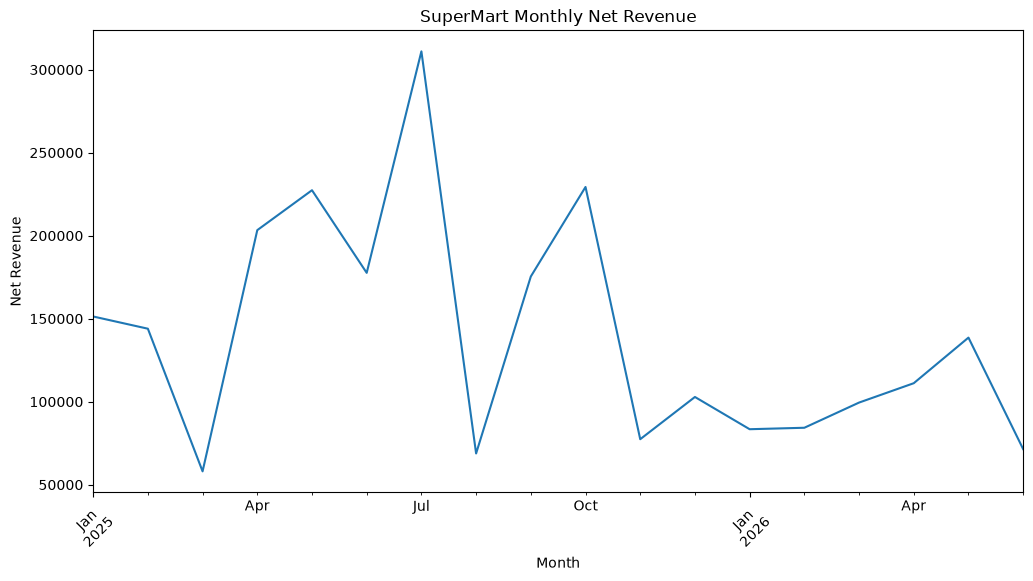

In [41]:
plt.figure(figsize=(12, 6))

monthly_revenue.plot(kind="line")

plt.title("SuperMart Monthly Net Revenue")
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)

plt.show()

In [42]:
category_summary = (
    sales_clean
    .groupby("Category")
    .agg(
        Revenue=("NetRevenue", "sum"),
        Profit=("Profit", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

category_summary

,Revenue,Profit
Category,,
Electronics,2.169763e+06,589962.5055
Groceries,8.732597e+04,25190.9736
Fresh Produce,7.189295e+04,21712.9492
Beverages,5.109031e+04,16259.3089
Cleaning,4.528225e+04,12302.2478
Household,2.659778e+04,8047.7818
Dairy,2.611639e+04,8046.3854
Personal Care,2.247575e+04,6680.7522
Snacks,1.042170e+04,4913.7050


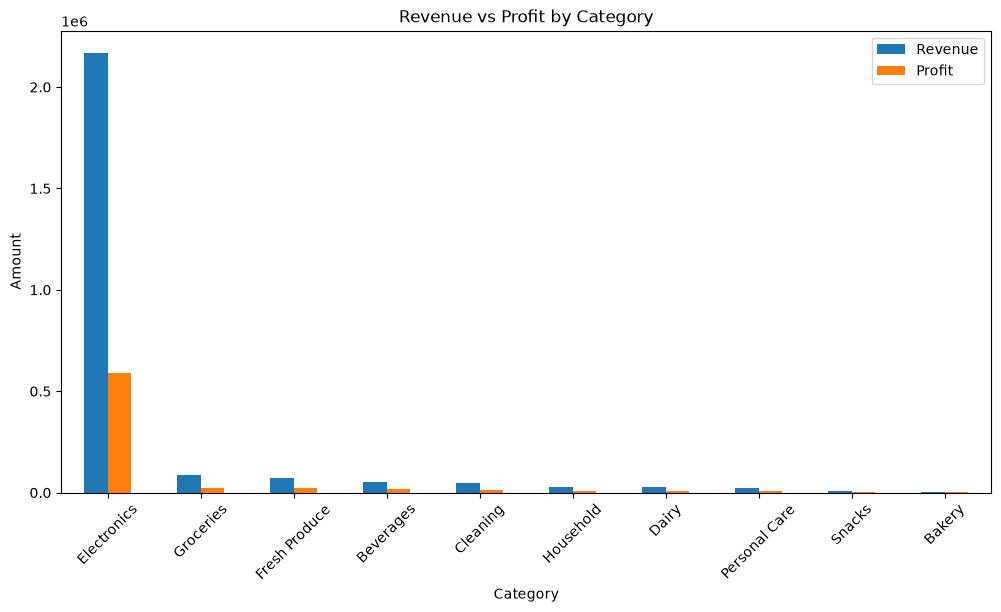

In [43]:
category_summary.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Revenue vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=45)

plt.show()

In [ ]:
##5.Business Analysis

The business analysis focuses on questions that are relevant to SuperMart's performance and decision-making.
The analysis examines revenue, profit, products, customers, regions, sales trends and operational performance.
The objective is to translate patterns identified in the data into meaningful business insights.

In [44]:
# Calculate the key overall performance metrics
total_revenue = sales_clean["NetRevenue"].sum()
total_profit = sales_clean["Profit"].sum()
average_order_value = sales_clean["NetRevenue"].mean()
overall_profit_margin = (total_profit / total_revenue) * 100

print(f"Total Net Revenue: R{total_revenue:,.2f}")
print(f"Total Profit: R{total_profit:,.2f}")
print(f"Average Order Value: R{average_order_value:,.2f}")
print(f"Overall Profit Margin: {overall_profit_margin:.2f}%")

Total Net Revenue: R2,514,656.89
Total Profit: R694,697.89
Average Order Value: R3,143.32
Overall Profit Margin: 27.63%


In [45]:
# Compare revenue, profit and profit margin across categories
category_analysis = (
    sales_clean
    .groupby("Category")
    .agg(
        Revenue=("NetRevenue", "sum"),
        Profit=("Profit", "sum"),
        Quantity_Sold=("Quantity", "sum")
    )
)

category_analysis["ProfitMargin"] = (
    category_analysis["Profit"] /
    category_analysis["Revenue"]
) * 100

category_analysis.sort_values("Revenue", ascending=False)

,Revenue,Profit,Quantity_Sold,ProfitMargin
Category,,,,
Electronics,2.169763e+06,589962.5055,809,27.190188
Groceries,8.732597e+04,25190.9736,733,28.847057
Fresh Produce,7.189295e+04,21712.9492,542,30.201778
Beverages,5.109031e+04,16259.3089,799,31.824644
Cleaning,4.528225e+04,12302.2478,464,27.167927
Household,2.659778e+04,8047.7818,265,30.257342
Dairy,2.611639e+04,8046.3854,522,30.809721
Personal Care,2.247575e+04,6680.7522,243,29.724265
Snacks,1.042170e+04,4913.7050,534,47.148763


In [46]:
# Analyse individual product performance
product_analysis = (
    sales_clean
    .groupby("ProductName")
    .agg(
        Revenue=("NetRevenue", "sum"),
        Profit=("Profit", "sum"),
        Quantity_Sold=("Quantity", "sum")
    )
)

product_analysis["ProfitMargin"] = (
    product_analysis["Profit"] /
    product_analysis["Revenue"]
) * 100

product_analysis.sort_values("Revenue", ascending=False).head(10)

,Revenue,Profit,Quantity_Sold,ProfitMargin
ProductName,,,,
LED Television,1.558147e+06,414347.1670,301,26.592300
Microwave Oven,4.296576e+05,117657.6130,260,27.384040
Bluetooth Speaker,1.819577e+05,57957.7255,248,31.852303
Beef Mince 1kg,4.019749e+04,12797.4875,274,31.836536
Rice 10kg,3.884724e+04,10887.2417,233,28.025778
Instant Coffee,3.371659e+04,9956.5915,264,29.530243
Chicken 2kg,3.169546e+04,8915.4617,268,28.128512
Laundry Powder,2.951910e+04,7519.1000,220,25.471983
Cooking Oil 2L,2.947914e+04,8119.1432,267,27.541992


In [49]:
# Compare regional revenue and profitability
region_analysis = (
    sales_clean
    .groupby("Region")
    .agg(
        Revenue=("NetRevenue", "sum"),
        Profit=("Profit", "sum"),
        Orders=("OrderID", "nunique")
    )
)

region_analysis["ProfitMargin"] = (
    region_analysis["Profit"] /
    region_analysis["Revenue"]
) * 100

region_analysis.sort_values("Revenue", ascending=False)

,Revenue,Profit,Orders,ProfitMargin
Region,,,,
Eastern Cape,696486.0882,185918.0882,218,26.693726
Free State,653996.2016,185015.2016,144,28.289950
Western Cape,452702.0817,120491.0817,154,26.615977
KwaZulu-Natal,399121.7648,112808.7648,161,28.264248
Gauteng,312350.7493,90464.7493,123,28.962552


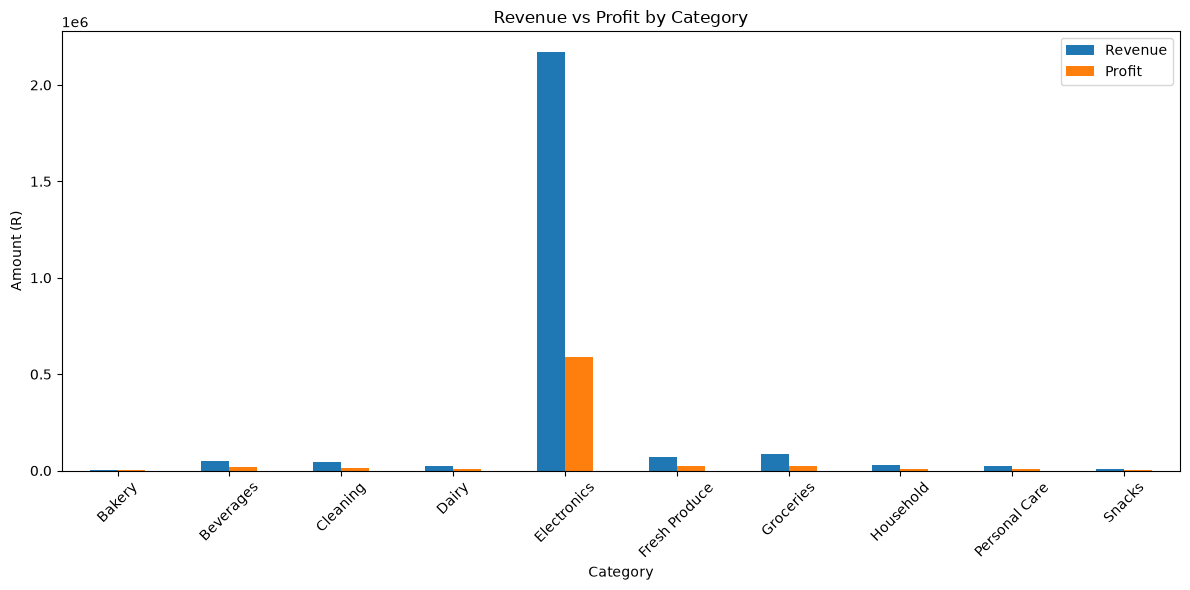

In [51]:
# Compare revenue and profit across product categories
category_analysis[["Revenue", "Profit"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Revenue vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount (R)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

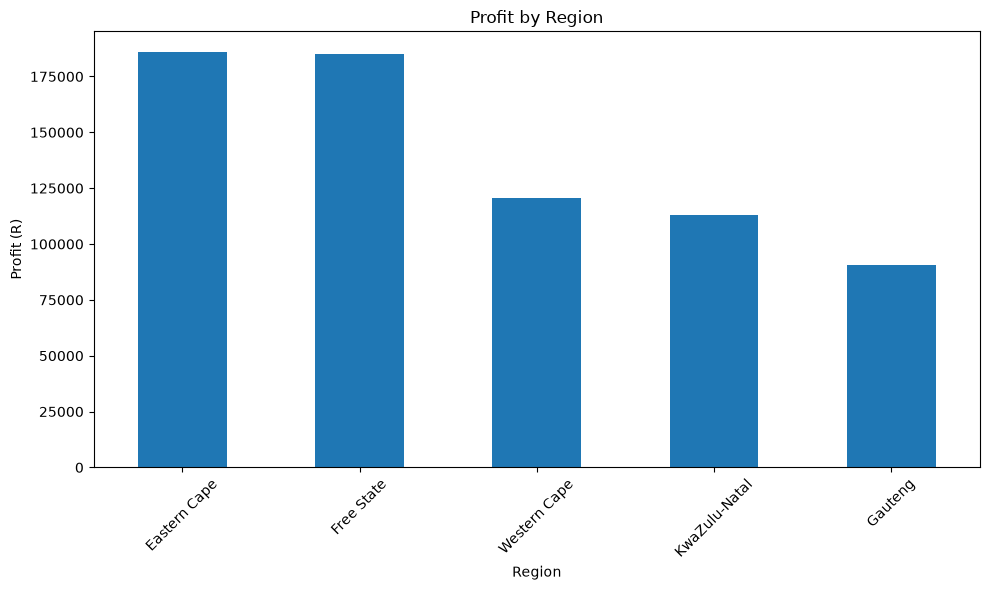

In [52]:
# Compare profit across regions
region_analysis["Profit"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit (R)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

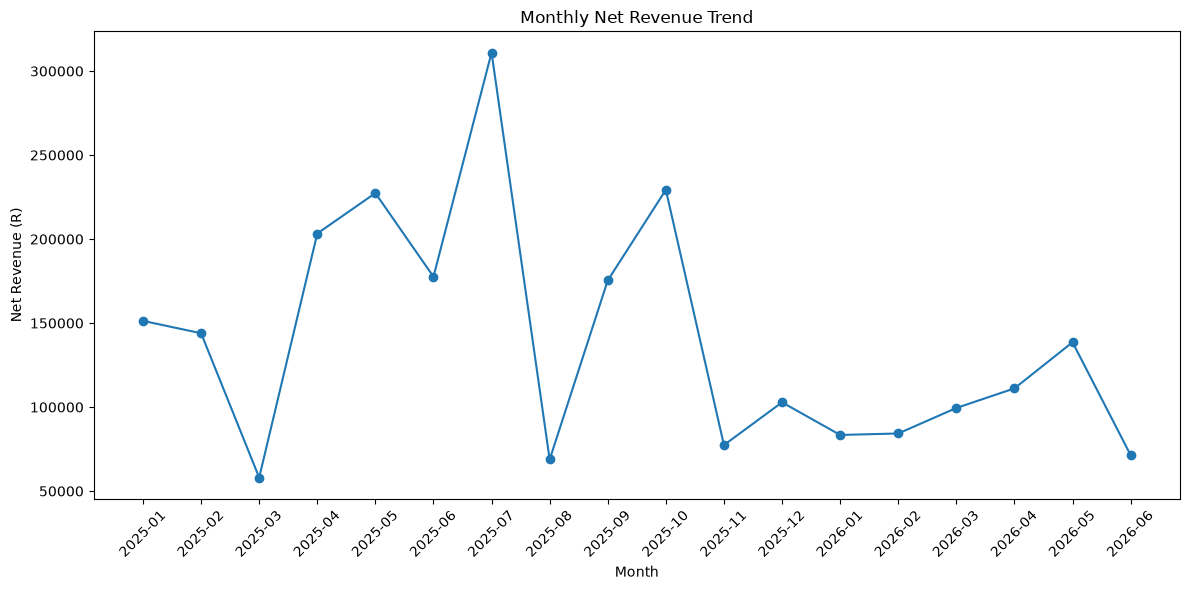

In [53]:
# Visualise monthly revenue trends
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Net Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Net Revenue (R)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

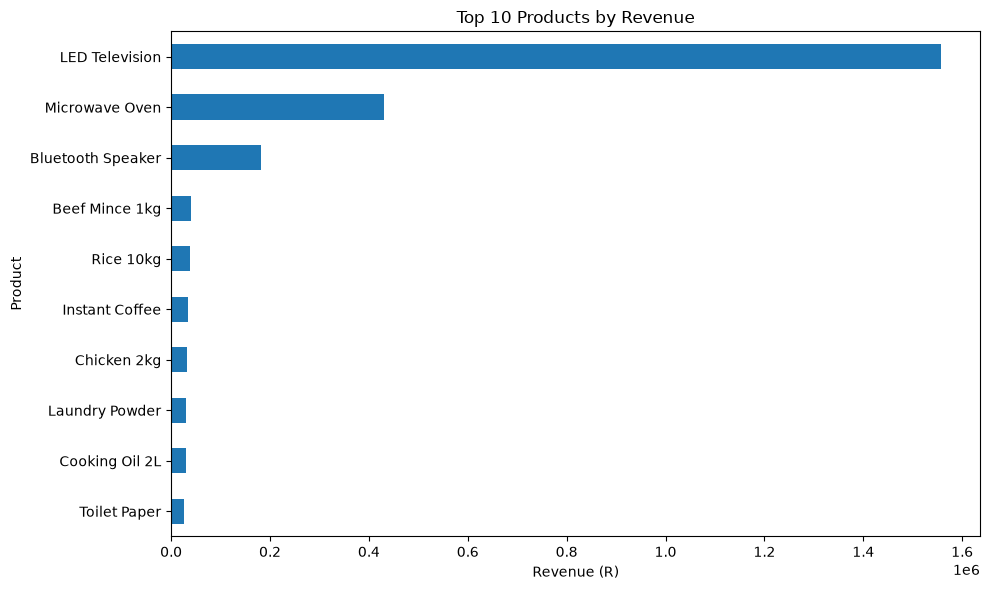

In [55]:
# Identify the ten products generating the most revenue
top_products = product_analysis.sort_values(
    "Revenue",
    ascending=False
).head(10)

top_products["Revenue"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (R)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [56]:
# Create a summary of category performance
category_summary = (
    sales_clean
    .groupby("Category")
    .agg(
        Revenue=("NetRevenue", "sum"),
        Profit=("Profit", "sum"),
        Orders=("OrderID", "nunique")
    )
)

category_summary["ProfitMargin"] = (
    category_summary["Profit"] /
    category_summary["Revenue"]
) * 100

category_summary.sort_values("Revenue", ascending=False)

,Revenue,Profit,Orders,ProfitMargin
Category,,,,
Electronics,2.169763e+06,589962.5055,120,27.190188
Groceries,8.732597e+04,25190.9736,111,28.847057
Fresh Produce,7.189295e+04,21712.9492,75,30.201778
Beverages,5.109031e+04,16259.3089,134,31.824644
Cleaning,4.528225e+04,12302.2478,81,27.167927
Household,2.659778e+04,8047.7818,42,30.257342
Dairy,2.611639e+04,8046.3854,84,30.809721
Personal Care,2.247575e+04,6680.7522,42,29.724265
Snacks,1.042170e+04,4913.7050,75,47.148763


In [57]:
# Identify categories with the highest revenue and profit margin
highest_revenue_category = category_summary["Revenue"].idxmax()
highest_margin_category = category_summary["ProfitMargin"].idxmax()

print("Highest Revenue Category:", highest_revenue_category)
print("Highest Profit Margin Category:", highest_margin_category)

Highest Revenue Category: Electronics
Highest Profit Margin Category: Snacks


In [58]:
# Identify high-revenue products with relatively low profit margins
product_analysis.sort_values(
    "Revenue",
    ascending=False
).head(20)

,Revenue,Profit,Quantity_Sold,ProfitMargin
ProductName,,,,
LED Television,1.558147e+06,414347.1670,301,26.592300
Microwave Oven,4.296576e+05,117657.6130,260,27.384040
Bluetooth Speaker,1.819577e+05,57957.7255,248,31.852303
Beef Mince 1kg,4.019749e+04,12797.4875,274,31.836536
Rice 10kg,3.884724e+04,10887.2417,233,28.025778
Instant Coffee,3.371659e+04,9956.5915,264,29.530243
Chicken 2kg,3.169546e+04,8915.4617,268,28.128512
Laundry Powder,2.951910e+04,7519.1000,220,25.471983
Cooking Oil 2L,2.947914e+04,8119.1432,267,27.541992


In [59]:
# Calculate each customer's contribution to total revenue
customer_analysis["RevenueShare"] = (
    customer_analysis["Revenue"] /
    customer_analysis["Revenue"].sum()
) * 100

customer_analysis.head(10)

NameError: name 'customer_analysis' is not defined

In [60]:
# Rank regions by profit margin
region_analysis.sort_values(
    "ProfitMargin",
    ascending=False
)

,Revenue,Profit,Orders,ProfitMargin
Region,,,,
Gauteng,312350.7493,90464.7493,123,28.962552
Free State,653996.2016,185015.2016,144,28.289950
KwaZulu-Natal,399121.7648,112808.7648,161,28.264248
Eastern Cape,696486.0882,185918.0882,218,26.693726
Western Cape,452702.0817,120491.0817,154,26.615977


In [61]:
# Create a high-level KPI summary for management
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Net Revenue",
        "Total Profit",
        "Average Order Value",
        "Overall Profit Margin"
    ],
    "Value": [
        total_revenue,
        total_profit,
        average_order_value,
        overall_profit_margin
    ]
})

kpi_summary

,Metric,Value
0,Total Net Revenue,2.514657e+06
1,Total Profit,6.946979e+05
2,Average Order Value,3.143321e+03
3,Overall Profit Margin,2.762595e+01


In [37]:
category_profit = (
    sales_clean
    .groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

category_profit

Category
Electronics      589962.5055
Groceries         25190.9736
Fresh Produce     21712.9492
Beverages         16259.3089
Cleaning          12302.2478
Household          8047.7818
Dairy              8046.3854
Personal Care      6680.7522
Snacks             4913.7050
Bakery             1581.2762
Name: Profit, dtype: float64

##6.Key Findings

- SuperMart generated approximatel**R2.51 million in net reven**.
- Total profit was approximate **R694,697**, giving an overall profit margin  **27%**.
- The average order value was approximaty **R343**.
- Overall, the business is profitable, but further analysis is needed to identify which products, regions and customers contribute most to revenue and profit.

##7.Business Recommendations

- Focus on the products and regions that contribute most to revenue and profitability.
- Monitor lower-margin products and review their pricing, costs and discount levels.
- Identify high-value customers and develop strategies to retain them.
- Continue monitoring revenue, profit margin and average order value as key performance indicators.

##8. Conclusion

The analysis provided SuperMart with a clearer understanding of its sales and profitability performance.
Python was used to clean, explore and analyse the data, identify important patterns and translate the
results into actionable business insights.